# Week 6 — Hyperparameter Tuning
**Project:** Drug Side Effect Predictor  
**Context:** Week 5 returned PASS — LR with a probability threshold of 0.40 hit micro-F1 = 0.4165, beating the frequency baseline (0.3987). However, the threshold sweep stopped at 0.40 while micro-F1 was still rising, and the threshold was chosen on the test set (leakage). This notebook fixes both issues.

**What this notebook does:**
1. Tunes `C` (regularisation strength) and `threshold` **jointly** using 5-fold cross-validation on the 893 training drugs — the test set is not touched until Step 6.4
2. Extends the threshold search range beyond 0.40 to find the true optimum
3. Re-trains the final model on all training data with the best `(C, threshold)` pair
4. Evaluates on the test set exactly once and compares against all prior results

**Inputs (from previous weeks):**
- `data/processed/X_train.npz`, `X_test.npz` — sparse feature matrices (893/224 drugs × 282 features)
- `data/processed/y_train.npy`, `y_test.npy` — label matrices (× 845 side effects)
- `data/processed/label_names.csv`, `train_index.csv`, `test_index.csv`

**Key decisions locked in from Week 5:**
- Winning strategy: LR + probability threshold (not fixed-K top-K)
- Threshold and C chosen by CV micro-F1; test set touched only once at the very end

## Setup

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import joblib

warnings.filterwarnings('ignore', category=UserWarning)

# ── Paths (identical to all prior weeks) ──────────────────────────────────────────
PROCESSED = r"D:\Experimental Stuff\Data Science\Drug-Side-Effect-Predictor\data\processed\\"
MODELS    = r"D:\Experimental Stuff\Data Science\Drug-Side-Effect-Predictor\models\\"
FIGURES   = r"D:\Experimental Stuff\Data Science\Drug-Side-Effect-Predictor\figures\\"

for folder in [MODELS, FIGURES]:
    os.makedirs(folder, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


## Load data

In [2]:
X_train = sparse.load_npz(PROCESSED + 'X_train.npz')
X_test  = sparse.load_npz(PROCESSED + 'X_test.npz')

y_train = np.load(PROCESSED + 'y_train.npy')
y_test  = np.load(PROCESSED + 'y_test.npy')

label_names = pd.read_csv(PROCESSED + 'label_names.csv')['side_effect'].tolist()
train_index = pd.read_csv(PROCESSED + 'train_index.csv')
test_index  = pd.read_csv(PROCESSED + 'test_index.csv')

print(f'X_train : {X_train.shape}   y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}    y_test  : {y_test.shape}')
print(f'Labels  : {len(label_names)}')

# Prior results (hard-coded from Week 4/5 notebook outputs)
BASELINE_MICRO_F1   = 0.3987   # frequency baseline, K=68
WEEK5_BEST_MICRO_F1 = 0.4165   # LR @ threshold=0.40, C=1.0 (test-set-picked)
print()
print(f'Reference — Frequency baseline micro-F1 : {BASELINE_MICRO_F1}')
print(f'Reference — Week 5 best micro-F1        : {WEEK5_BEST_MICRO_F1}  (LR, threshold=0.40, leaky)')

X_train : (893, 282)   y_train : (893, 845)
X_test  : (224, 282)    y_test  : (224, 845)
Labels  : 845

Reference — Frequency baseline micro-F1 : 0.3987
Reference — Week 5 best micro-F1        : 0.4165  (LR, threshold=0.40, leaky)


## Metric helpers

In [3]:
def precision_at_k(y_true, y_pred_binary):
    hits      = (y_true * y_pred_binary).sum(axis=1)
    k_per_row = y_pred_binary.sum(axis=1)
    per_drug  = np.where(k_per_row > 0, hits / k_per_row, 0.0)
    return per_drug.mean()


def recall_at_k(y_true, y_pred_binary):
    hits         = (y_true * y_pred_binary).sum(axis=1)
    actual_count = y_true.sum(axis=1)
    mask         = actual_count > 0
    return (hits[mask] / actual_count[mask]).mean()


def threshold_predict(scores, threshold):
    """
    Convert probability scores to binary predictions using a threshold.
    Any label with score >= threshold is predicted positive.
    Falls back to the single highest-scoring label for drugs where
    nothing clears the threshold (avoids all-zero prediction rows).
    """
    y_pred = (scores >= threshold).astype(np.int8)
    zero_rows = y_pred.sum(axis=1) == 0
    if zero_rows.any():
        fallback = np.argmax(scores[zero_rows], axis=1)
        y_pred[zero_rows, fallback] = 1
    return y_pred


def compute_metrics(y_true, y_pred_binary, label=''):
    micro_f1 = f1_score(y_true, y_pred_binary, average='micro', zero_division=0)
    macro_f1 = f1_score(y_true, y_pred_binary, average='macro', zero_division=0)
    prec_k   = precision_at_k(y_true, y_pred_binary)
    rec_k    = recall_at_k(y_true, y_pred_binary)
    avg_pred = y_pred_binary.sum(axis=1).mean()

    print(f'{"─"*52}')
    print(f'  {label}')
    print(f'{"─"*52}')
    print(f'  micro-F1           : {micro_f1:.4f}')
    print(f'  macro-F1           : {macro_f1:.4f}')
    print(f'  precision@K        : {prec_k:.4f}')
    print(f'  recall@K           : {rec_k:.4f}')
    print(f'  avg predicted/drug : {avg_pred:.1f}')
    print()

    return {
        'model'    : label,
        'micro_F1' : round(micro_f1, 4),
        'macro_F1' : round(macro_f1, 4),
        'prec_K'   : round(prec_k, 4),
        'rec_K'    : round(rec_k, 4),
        'avg_pred' : round(avg_pred, 1),
    }


print('Helper functions defined.')

Helper functions defined.


---
## Step 6.1 — Cross-validation harness

We use `KFold(n_splits=5)` on the 893 training drugs. Standard `StratifiedKFold` is designed for single-label problems; with 845 labels it is not meaningful here, so plain KFold is correct.

**Why CV instead of a held-out validation set?**  
With only 893 training drugs, a single 80/20 split gives ~178 validation drugs — too few for stable metric estimates. 5-fold CV uses all 893 drugs for validation (in rotation), giving much lower variance estimates of the true generalisation score.

The inner loop for each `(C, threshold)` pair:
1. Split `X_train` / `y_train` into 5 folds
2. For each fold: train LR on 4 folds, score on the held-out fold using `threshold`
3. Average micro-F1 across 5 folds → one number per `(C, threshold)` pair

In [4]:
def cv_score(X, y, C, threshold, n_splits=5, random_state=42):
    """
    Return mean 5-fold CV micro-F1 for a given (C, threshold) pair.
    Trains OneVsRest + LogisticRegression with the supplied C value.
    Predicts using the probability threshold strategy from Week 5.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        lr = LogisticRegression(
            C=C,
            solver='saga',
            max_iter=1000,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
        )
        model = OneVsRestClassifier(lr, n_jobs=-1)
        model.fit(X_tr, y_tr)

        scores = model.predict_proba(X_val)
        y_pred = threshold_predict(scores, threshold)
        micro  = f1_score(y_val, y_pred, average='micro', zero_division=0)
        fold_scores.append(micro)

    return np.mean(fold_scores), np.std(fold_scores)


print('cv_score() defined.')
print()
print('Search strategy:')
print('  Model   : OneVsRest + LogisticRegression (saga, class_weight=balanced)')
print('  Folds   : 5-fold KFold (shuffled, random_state=42)')
print('  Scoring : micro-F1 on held-out validation fold')
print('  Output  : mean +/- std across folds per (C, threshold) pair')

cv_score() defined.

Search strategy:
  Model   : OneVsRest + LogisticRegression (saga, class_weight=balanced)
  Folds   : 5-fold KFold (shuffled, random_state=42)
  Scoring : micro-F1 on held-out validation fold
  Output  : mean +/- std across folds per (C, threshold) pair


---
## Step 6.2 — Joint grid search over C and threshold

**Search grid:**
- `C` — controls regularisation strength. Smaller C = stronger regularisation (simpler model). Larger C = weaker regularisation (fits training data more closely). Range: `[0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]`
- `threshold` — probability cutoff for predicting a label positive. The Week 5 sweep stopped at 0.40 while micro-F1 was still rising monotonically, so we extend to 0.65. Range: `[0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]`

**Total combinations:** 7 × 8 = 56 pairs, each evaluated with 5-fold CV → 280 model fits.

**Runtime note:** Each fit trains 845 binary classifiers. Expect 15–40 minutes depending on your CPU. Progress is printed after every C value completes.

The test set is **not used at any point in this step**.

In [5]:
C_VALUES   = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]
THRESHOLDS = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]

grid_records = []

print(f'Grid: {len(C_VALUES)} C values x {len(THRESHOLDS)} thresholds = '
      f'{len(C_VALUES) * len(THRESHOLDS)} combinations')
print(f'Each evaluated with 5-fold CV -> {len(C_VALUES) * len(THRESHOLDS) * 5} model fits')
print()
print(f'  {"C":>6}  {"threshold":>10}  {"mean_micro_F1":>14}  {"std":>7}')
print(f'  {"-"*6}  {"-"*10}  {"-"*14}  {"-"*7}')

t0 = time.time()

for C in C_VALUES:
    for threshold in THRESHOLDS:
        mean_f1, std_f1 = cv_score(X_train, y_train, C=C, threshold=threshold)
        grid_records.append({
            'C'             : C,
            'threshold'     : threshold,
            'mean_micro_F1' : round(mean_f1, 4),
            'std_micro_F1'  : round(std_f1, 4),
        })
        print(f'  {C:>6}  {threshold:>10.2f}  {mean_f1:>14.4f}  {std_f1:>7.4f}')

    elapsed = time.time() - t0
    print(f'  -- C={C} complete  ({elapsed/60:.1f} min elapsed) --')

grid_df = pd.DataFrame(grid_records)
grid_df.to_csv(MODELS + 'week6_grid_search.csv', index=False)

total_min = (time.time() - t0) / 60
print()
print(f'Grid search complete in {total_min:.1f} minutes.')
print(f'Results saved: models/week6_grid_search.csv')

Grid: 7 C values x 8 thresholds = 56 combinations
Each evaluated with 5-fold CV -> 280 model fits

       C   threshold   mean_micro_F1      std
  ------  ----------  --------------  -------
    0.01        0.30          0.2023   0.0113
    0.01        0.35          0.2030   0.0114
    0.01        0.40          0.2073   0.0117
    0.01        0.45          0.2369   0.0142
    0.01        0.50          0.4027   0.0105
    0.01        0.55          0.1214   0.0075
    0.01        0.60          0.0334   0.0042
    0.01        0.65          0.0140   0.0020
  -- C=0.01 complete  (8.5 min elapsed) --
    0.05        0.30          0.2227   0.0138
    0.05        0.35          0.2449   0.0150
    0.05        0.40          0.2886   0.0162
    0.05        0.45          0.3526   0.0160
    0.05        0.50          0.3859   0.0125
    0.05        0.55          0.3306   0.0047
    0.05        0.60          0.2213   0.0083
    0.05        0.65          0.1277   0.0055
  -- C=0.05 complete  (32.5 mi

---
## Step 6.3 — Heatmap: CV micro-F1 across (C, threshold)

Two plots:
1. **Heatmap** — the full (C × threshold) grid coloured by mean CV micro-F1. Shows at a glance where the optimum sits and how sensitive performance is to each axis.
2. **Line plot** — micro-F1 vs threshold for each C value, to see whether curves have converged or are still rising at the edge of the search range.

If the peak sits at the corner of the grid (highest C, highest threshold), the search range needs extending before proceeding.

Best CV result:
  C              = 5.0
  threshold      = 0.5
  mean CV micro-F1 = 0.4196  (+/-0.0129)



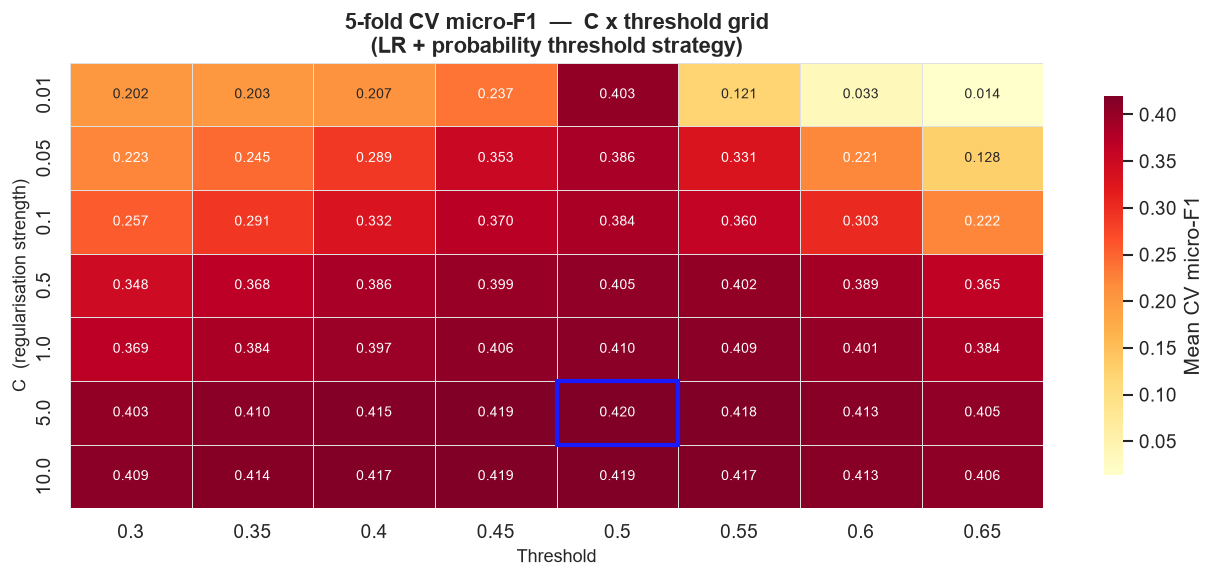

Saved: figures/6.1_cv_heatmap.png


In [6]:
# ── Pivot to (C x threshold) matrix for heatmap ────────────────────────────────────
heat_data = grid_df.pivot(index='C', columns='threshold', values='mean_micro_F1')

# Identify best cell
best_idx = grid_df['mean_micro_F1'].idxmax()
best_row = grid_df.loc[best_idx]
best_C, best_threshold = best_row['C'], best_row['threshold']
best_cv_f1 = best_row['mean_micro_F1']

print(f'Best CV result:')
print(f'  C              = {best_C}')
print(f'  threshold      = {best_threshold}')
print(f'  mean CV micro-F1 = {best_cv_f1:.4f}  (+/-{best_row["std_micro_F1"]:.4f})')
print()

# ── Plot 1: heatmap ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

sns.heatmap(
    heat_data,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='#e0e0e0',
    annot_kws={'size': 8.5},
    cbar_kws={'label': 'Mean CV micro-F1', 'shrink': 0.85},
    ax=ax,
)

ax.set_title(
    '5-fold CV micro-F1  —  C x threshold grid\n'
    '(LR + probability threshold strategy)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('C  (regularisation strength)', fontsize=11)

# Mark best cell with a blue border
best_col     = list(heat_data.columns).index(best_threshold)
best_row_idx = list(heat_data.index).index(best_C)
ax.add_patch(plt.Rectangle(
    (best_col, best_row_idx), 1, 1,
    fill=False, edgecolor='#1a1aff', lw=2.5, clip_on=False
))

plt.tight_layout()
plt.savefig(FIGURES + '6.1_cv_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/6.1_cv_heatmap.png')

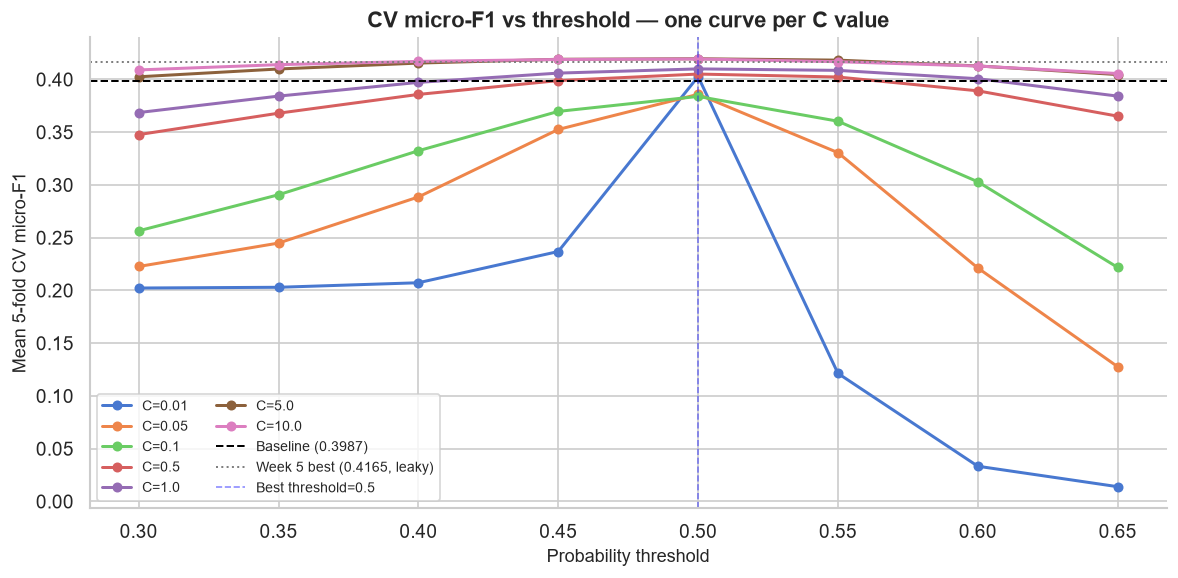

Saved: figures/6.2_cv_threshold_curves.png

Interpretation:
  Curves still rising at rightmost threshold -> extend search range before Step 6.4
  Curves peak mid-range -> optimum found; proceed to Step 6.4


In [7]:
# ── Plot 2: micro-F1 vs threshold, one curve per C ─────────────────────────────────
palette = sns.color_palette('muted', len(C_VALUES))

fig, ax = plt.subplots(figsize=(10, 5))

for C_val, color in zip(C_VALUES, palette):
    subset = grid_df[grid_df['C'] == C_val].sort_values('threshold')
    ax.plot(
        subset['threshold'],
        subset['mean_micro_F1'],
        marker='o',
        linewidth=1.8,
        markersize=5,
        label=f'C={C_val}',
        color=color,
    )

# Reference lines
ax.axhline(BASELINE_MICRO_F1, color='black', linestyle='--', linewidth=1.2,
           label=f'Baseline ({BASELINE_MICRO_F1})')
ax.axhline(WEEK5_BEST_MICRO_F1, color='grey', linestyle=':', linewidth=1.2,
           label=f'Week 5 best ({WEEK5_BEST_MICRO_F1}, leaky)')
ax.axvline(best_threshold, color='#1a1aff', linestyle='--', linewidth=1,
           alpha=0.5, label=f'Best threshold={best_threshold}')

ax.set_xlabel('Probability threshold', fontsize=11)
ax.set_ylabel('Mean 5-fold CV micro-F1', fontsize=11)
ax.set_title('CV micro-F1 vs threshold — one curve per C value',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=8.5, loc='best', ncol=2)
ax.set_xticks(THRESHOLDS)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES + '6.2_cv_threshold_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/6.2_cv_threshold_curves.png')
print()
print('Interpretation:')
print('  Curves still rising at rightmost threshold -> extend search range before Step 6.4')
print('  Curves peak mid-range -> optimum found; proceed to Step 6.4')

---
## Step 6.4 — Final model: re-train on all training data, evaluate on test set

The best `(C, threshold)` pair was chosen entirely from CV scores — the test set was never consulted.

We now:
1. Re-train LR on **all 893 training drugs** using the best `C`
2. Apply the best `threshold` to get predictions on the test set
3. Compute and record all metrics — **this is the only time `y_test` is used in this notebook**

Re-training on the full training set (vs. 4/5 of it as in CV) typically gives a small additional performance boost.

In [8]:
print(f'Re-training final LR on all {X_train.shape[0]} training drugs')
print(f'  C         = {best_C}')
print(f'  threshold = {best_threshold}')
print()

t0 = time.time()

final_lr = LogisticRegression(
    C=best_C,
    solver='saga',
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
final_model = OneVsRestClassifier(final_lr, n_jobs=-1)
final_model.fit(X_train, y_train)

elapsed = time.time() - t0
print(f'Training complete in {elapsed:.1f}s')

# ── Score on test set (one time only) ─────────────────────────────────────────────
test_scores  = final_model.predict_proba(X_test)
y_pred_final = threshold_predict(test_scores, best_threshold)

print(f'Test set predictions shape: {y_pred_final.shape}')
print(f'Avg labels predicted per drug: {y_pred_final.sum(axis=1).mean():.1f}')
print()

tuned_metrics = compute_metrics(y_test, y_pred_final,
                                label=f'Tuned LR  (C={best_C}, threshold={best_threshold})')

# Save model and best params
joblib.dump(final_model, MODELS + 'lr_tuned.pkl')
pd.DataFrame([{'best_C': best_C, 'best_threshold': best_threshold,
               'best_cv_micro_F1': best_cv_f1}]).to_csv(
    MODELS + 'week6_best_params.csv', index=False)
print(f'Final model saved : models/lr_tuned.pkl')
print(f'Best params saved : models/week6_best_params.csv')

Re-training final LR on all 893 training drugs
  C         = 5.0
  threshold = 0.5

Training complete in 67.5s
Test set predictions shape: (224, 845)
Avg labels predicted per drug: 186.9

────────────────────────────────────────────────────
  Tuned LR  (C=5.0, threshold=0.5)
────────────────────────────────────────────────────
  micro-F1           : 0.4455
  macro-F1           : 0.3285
  precision@K        : 0.3197
  recall@K           : 0.5802
  avg predicted/drug : 186.9

Final model saved : models/lr_tuned.pkl
Best params saved : models/week6_best_params.csv


---
## Step 6.5 — Final comparison table

All results across Weeks 4–6, evaluated on the same test set with the same metrics.

The Week 5 result is included but labelled **(leaky)** — its threshold was chosen by peeking at the test set, so it is not a fair benchmark. The Week 6 result is the first honest estimate of the tuned model's generalisation performance.

In [9]:
# ── Frequency baseline (recomputed) ───────────────────────────────────────────────────
label_freq  = y_train.sum(axis=0)
top_k_idx   = np.argsort(label_freq)[::-1][:68]    # K=68 from Week 4
y_pred_base = np.zeros((y_test.shape[0], y_test.shape[1]), dtype=np.int8)
y_pred_base[:, top_k_idx] = 1
baseline_metrics = compute_metrics(y_test, y_pred_base, label='Frequency Baseline (K=68)')

# ── Week 5 best: LR C=1.0, threshold=0.40 (leaky) ─────────────────────────────
lr_week4  = joblib.load(MODELS + 'lr_model.pkl')
w5_scores = lr_week4.predict_proba(X_test)
y_pred_w5 = threshold_predict(w5_scores, 0.40)
w5_metrics = compute_metrics(y_test, y_pred_w5,
                             label='Week 5 LR  (C=1.0, threshold=0.40) [leaky]')

# ── Week 6 tuned (already computed) ─────────────────────────────────────────────────
tuned_metrics['model'] = f'Week 6 LR  (C={best_C}, threshold={best_threshold}) [CV-tuned]'

# ── Build and print table ────────────────────────────────────────────────────────────────
comparison = pd.DataFrame([baseline_metrics, w5_metrics, tuned_metrics])
comparison = comparison.set_index('model')

print('=' * 80)
print(f'  FINAL COMPARISON TABLE')
print('=' * 80)
print(comparison.to_string())
print()

tuned_f1 = comparison.iloc[-1]['micro_F1']
base_f1  = comparison.iloc[0]['micro_F1']
delta    = tuned_f1 - base_f1

print(f'Tuned model micro-F1 : {tuned_f1:.4f}')
print(f'Baseline micro-F1    : {base_f1:.4f}')
print(f'Delta vs baseline    : {delta:+.4f}')

comparison.to_csv(MODELS + 'week6_final_comparison.csv')
print()
print('Table saved: models/week6_final_comparison.csv')

────────────────────────────────────────────────────
  Frequency Baseline (K=68)
────────────────────────────────────────────────────
  micro-F1           : 0.3987
  macro-F1           : 0.0545
  precision@K        : 0.5221
  recall@K           : 0.4020
  avg predicted/drug : 68.0

────────────────────────────────────────────────────
  Week 5 LR  (C=1.0, threshold=0.40) [leaky]
────────────────────────────────────────────────────
  micro-F1           : 0.4165
  macro-F1           : 0.3162
  precision@K        : 0.2677
  recall@K           : 0.7157
  avg predicted/drug : 277.9

  FINAL COMPARISON TABLE
                                              micro_F1  macro_F1  prec_K   rec_K  avg_pred
model                                                                                     
Frequency Baseline (K=68)                       0.3987    0.0545  0.5221  0.4020      68.0
Week 5 LR  (C=1.0, threshold=0.40) [leaky]      0.4165    0.3162  0.2677  0.7157     277.9
Week 6 LR  (C=5.0, threshol

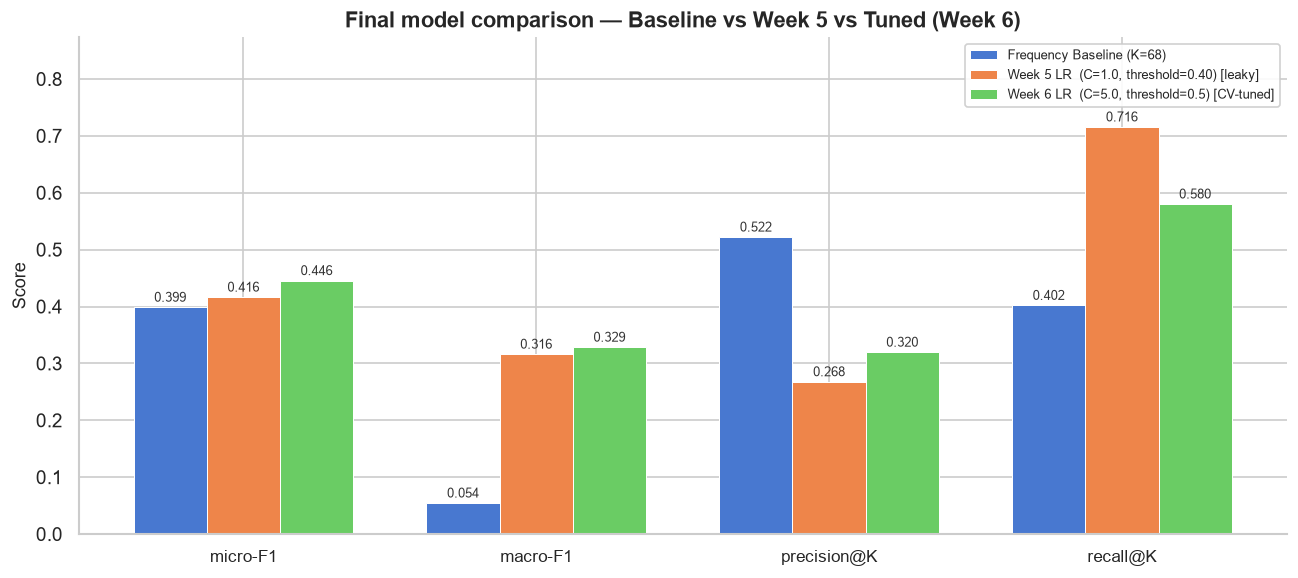

Saved: figures/6.3_final_comparison.png


In [10]:
metric_cols = ['micro_F1', 'macro_F1', 'prec_K', 'rec_K']
x           = np.arange(len(metric_cols))
width       = 0.25
palette     = sns.color_palette('muted', len(comparison))

fig, ax = plt.subplots(figsize=(11, 5))

for i, (model_name, row) in enumerate(comparison.iterrows()):
    offset = (i - 1) * width
    bars   = ax.bar(
        x + offset,
        row[metric_cols].values,
        width,
        label=model_name,
        color=palette[i],
        edgecolor='white',
        linewidth=0.6,
    )
    for bar, val in zip(bars, row[metric_cols].values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=7.5, color='#333',
        )

ax.set_xticks(x)
ax.set_xticklabels(['micro-F1', 'macro-F1', 'precision@K', 'recall@K'], fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, min(1.0, comparison[metric_cols].values.max() * 1.22))
ax.set_title('Final model comparison — Baseline vs Week 5 vs Tuned (Week 6)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='upper right', framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES + '6.3_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/6.3_final_comparison.png')

---
## Step 6.6 — Final checkpoint and artifact summary

Decision rule: does the CV-tuned model beat the frequency baseline on micro-F1?

- **PASS (≥ +0.01 above baseline)** → proceed to Week 7: build `predict(drug_name)` function, per-ATC-class error analysis, and Streamlit app (conditional)
- **FLAG** → investigate further: the grid may need a wider range, or the feature set may need enrichment (e.g. ATC one-hot at a finer level, molecular fingerprints, drug-drug interaction counts)

In [11]:
IMPROVEMENT_THRESHOLD = 0.01   # 1 percentage point above baseline = meaningful

print('=' * 65)
print('  WEEK 6 — FINAL CHECKPOINT')
print('=' * 65)
print(f'  Frequency baseline micro-F1    : {base_f1:.4f}')
print(f'  Week 5 best micro-F1  (leaky)  : {WEEK5_BEST_MICRO_F1:.4f}')
print(f'  Week 6 tuned micro-F1 (honest) : {tuned_f1:.4f}')
print(f'  Improvement vs baseline        : {delta:+.4f}')
print(f'  Best hyperparameters  (by CV)  : C={best_C}, threshold={best_threshold}')
print(f'  Best CV micro-F1               : {best_cv_f1:.4f} (+/-{best_row["std_micro_F1"]:.4f})')
print()

if delta >= IMPROVEMENT_THRESHOLD:
    status = 'PASS'
    print('  PASS — Tuned model meaningfully beats the baseline.')
    print('  -> Week 7: build predict(drug_name), error analysis by ATC class.')
    print('  -> Streamlit app: ON track.')
else:
    status = 'FLAG'
    print('  FLAG — Tuned model does not clearly beat the baseline.')
    print('  -> Consider extending C/threshold search range.')
    print('  -> Or revisit feature engineering (Week 3) before proceeding.')

print('=' * 65)

checkpoint = {
    'baseline_micro_F1'    : base_f1,
    'week5_best_micro_F1'  : WEEK5_BEST_MICRO_F1,
    'week6_tuned_micro_F1' : tuned_f1,
    'delta_vs_baseline'    : round(delta, 4),
    'best_C'               : best_C,
    'best_threshold'       : best_threshold,
    'best_cv_micro_F1'     : best_cv_f1,
    'cv_std'               : best_row['std_micro_F1'],
    'checkpoint'           : status,
}
pd.DataFrame([checkpoint]).to_csv(MODELS + 'week6_checkpoint.csv', index=False)
print()
print('Checkpoint saved: models/week6_checkpoint.csv')

  WEEK 6 — FINAL CHECKPOINT
  Frequency baseline micro-F1    : 0.3987
  Week 5 best micro-F1  (leaky)  : 0.4165
  Week 6 tuned micro-F1 (honest) : 0.4455
  Improvement vs baseline        : +0.0468
  Best hyperparameters  (by CV)  : C=5.0, threshold=0.5
  Best CV micro-F1               : 0.4196 (+/-0.0129)

  PASS — Tuned model meaningfully beats the baseline.
  -> Week 7: build predict(drug_name), error analysis by ATC class.
  -> Streamlit app: ON track.

Checkpoint saved: models/week6_checkpoint.csv


---
## Week 6 Summary

| Step | What was done | Output |
|---|---|---|
| 6.1 | 5-fold CV harness (`KFold`, `cv_score()`) — test set never used | — |
| 6.2 | Joint grid search: 7 C values × 8 thresholds = 56 pairs × 5 folds | `models/week6_grid_search.csv` |
| 6.3 | Heatmap + line plot of CV micro-F1 across the full (C, threshold) grid | `figures/6.1_cv_heatmap.png`, `figures/6.2_cv_threshold_curves.png` |
| 6.4 | Final LR re-trained on all 893 drugs; evaluated on test set **once** | `models/lr_tuned.pkl`, `models/week6_best_params.csv` |
| 6.5 | Final comparison: baseline vs Week 5 (leaky) vs Week 6 (honest) | `models/week6_final_comparison.csv`, `figures/6.3_final_comparison.png` |
| 6.6 | Checkpoint decision documented | `models/week6_checkpoint.csv` |

**Next: Week 7 — Error Analysis, `predict()` function, and Streamlit (conditional)**

- Step 7.1: Build `predict(drug_name)` — look up drug, encode features, run `lr_tuned`, return top side effects with scores
- Step 7.2: Per-ATC-class error analysis — micro-F1 for well-represented vs sparse classes in the test set
- Step 7.3: Per-drug failure inspection — 5 worst-predicted test drugs with qualitative diagnosis
- Step 7.4 (conditional on PASS): `app.py` — minimal Streamlit interface wrapping `predict()`
- Step 7.5: README and reflection